# Jeffreys-prior network reconstruction: synthetic example

This notebook demonstrates the low-level use of `trade_jeffreys` with explicit
network inputs, matching the setup in the paper:

- node fitness values `x_i`;
- block labels for all nodes;
- observed total number of links `L_total`;
- observed number of intra-block links `L_same`;
- observed number of inter-block links `L_diff`;
- an optional binary adjacency matrix for likelihood, ROC AUC, PR AUC, AIC, and BIC.

Associated article: **Network Reconstruction via Jeffreys Prior under Missing Sufficient Statistics**
by Minh Duc Duong and Diego Garlaschelli.

Google Scholar record:
<https://scholar.google.com/citations?view_op=view_citation&hl=en&user=ps0A1EYAAAAJ&citation_for_view=ps0A1EYAAAAJ:d1gkVwhDpl0C>

In [1]:
# Add the project root to sys.path so that the notebook can be executed from
# either the package root or the notebooks/ directory.
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
for candidate in [cwd, cwd.parent, cwd.parent.parent, cwd.parent.parent.parent]:
    if (candidate / "trade_jeffreys" / "__init__.py").exists():
        sys.path.insert(0, str(candidate))
        print(f"Using project root: {candidate}")
        break
else:
    raise RuntimeError("Could not locate the trade_jeffreys package folder.")

Using project root: C:\Users\minhd\Documents\GitHub\Network-reconstruction-Jeffrey


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from trade_jeffreys import (
    fit_true_params_from_link_counts,
    run_jeffreys_pipeline,
    compute_metrics_true_and_median,
    plot_curve_2d,
    plot_curve_3d,
)

## 1. Define network-level inputs

The package parameterization uses `g = exp(beta)`. The probability model is

\[
p_{ij}(g, \gamma) = \frac{g e^{\gamma R_{ij}} x_i x_j}
{1 + g e^{\gamma R_{ij}} x_i x_j},
\]

where `R_ij = 1` when two nodes share the same block and `R_ij = 0` otherwise.

In [3]:
# Synthetic node table. Replace these values with your own network inputs.
node_ids = [f"N{i:02d}" for i in range(18)]
block_labels = (
    ["Block_A"] * 6 +
    ["Block_B"] * 6 +
    ["Block_C"] * 6
)

# Positive node fitnesses. In trade applications, this is often normalized GDP.
fitness = np.array([
    1.55, 1.40, 1.20, 1.05, 0.90, 0.75,
    1.45, 1.30, 1.10, 0.95, 0.80, 0.65,
    1.35, 1.15, 1.00, 0.85, 0.70, 0.55,
])
fitness = fitness / fitness.max()

country_df = pd.DataFrame({
    "ISO3": node_ids,
    "region": block_labels,
    "fitness": fitness,
})

# Observed sufficient statistics for the full-information reference model.
# The Jeffreys-prior method below will use only L_total.
L_same = 18
L_diff = 25
L_total = L_same + L_diff

country_df.head()

,ISO3,region,fitness
0,N00,Block_A,1.000000
1,N01,Block_A,0.903226
2,N02,Block_A,0.774194
3,N03,Block_A,0.677419
4,N04,Block_A,0.580645


## 2. Build a binary adjacency matrix with the requested counts

The full-information reference fit requires `L_same` and `L_diff`. Metrics such
as ROC AUC and PR AUC require a binary adjacency matrix. In a real use case, this
matrix is the observed network. Here we construct a deterministic synthetic
network with exactly the requested intra-block and inter-block link counts.

In [4]:
def build_adjacency_from_counts(country_df, L_same, L_diff, seed=7):
    """Construct a symmetric binary adjacency matrix with exact block counts."""
    rng = np.random.default_rng(seed)
    x = country_df["fitness"].to_numpy(float)
    labels = country_df["region"].astype(str).to_numpy()
    n = len(country_df)

    same_pairs = []
    diff_pairs = []
    for i in range(n):
        for j in range(i + 1, n):
            same = labels[i] == labels[j]
            # Fitness-based score plus tiny random jitter to break ties.
            score = x[i] * x[j] * (1.35 if same else 1.0) + 1e-6 * rng.normal()
            if same:
                same_pairs.append((score, i, j))
            else:
                diff_pairs.append((score, i, j))

    if L_same > len(same_pairs):
        raise ValueError("L_same exceeds the number of same-block pairs.")
    if L_diff > len(diff_pairs):
        raise ValueError("L_diff exceeds the number of different-block pairs.")

    A = np.zeros((n, n), dtype=int)
    for _, i, j in sorted(same_pairs, reverse=True)[:L_same]:
        A[i, j] = A[j, i] = 1
    for _, i, j in sorted(diff_pairs, reverse=True)[:L_diff]:
        A[i, j] = A[j, i] = 1

    return pd.DataFrame(A, index=country_df["ISO3"], columns=country_df["ISO3"])

adj_matrix = build_adjacency_from_counts(country_df, L_same, L_diff)

# Verify the counts.
labels = country_df["region"].to_numpy()
A = adj_matrix.to_numpy()
count_same = 0
count_diff = 0
for i in range(len(country_df)):
    for j in range(i + 1, len(country_df)):
        if A[i, j] == 1:
            if labels[i] == labels[j]:
                count_same += 1
            else:
                count_diff += 1

pd.DataFrame({
    "quantity": ["L_same", "L_diff", "L_total"],
    "target": [L_same, L_diff, L_total],
    "observed_in_adj_matrix": [count_same, count_diff, int(A.sum() / 2)],
})

,quantity,target,observed_in_adj_matrix
0,L_same,18,18
1,L_diff,25,25
2,L_total,43,43


## 3. Visualize the observed network by block

Before fitting the reconstruction models, it is often useful to inspect the
observed binary network. The plot below groups nodes by their block labels and
colors nodes by cluster. This mirrors the paper-style network visualizations
where countries are colored according to their economic region.


(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Synthetic observed network grouped by block'}>)

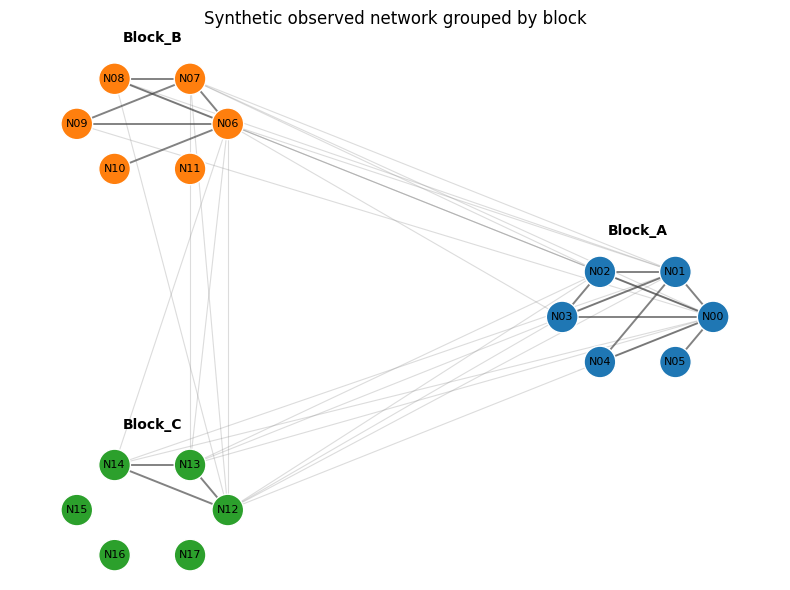

In [5]:
def plot_network_by_block(adj_matrix, country_df, block_col="region", node_col="ISO3", seed=11):
    """Plot an undirected binary network with nodes grouped and colored by block."""
    labels = country_df[node_col].astype(str).to_list()
    blocks = country_df[block_col].astype(str).to_numpy()

    G = nx.from_pandas_adjacency(adj_matrix.astype(int))
    G = nx.relabel_nodes(G, {node: str(node) for node in G.nodes()})

    unique_blocks = list(pd.unique(blocks))
    block_to_nodes = {
        block: country_df.loc[country_df[block_col].astype(str) == block, node_col].astype(str).to_list()
        for block in unique_blocks
    }

    # Deterministic clustered layout: block centers on a large circle,
    # nodes in each block arranged on a smaller local circle.
    angles = np.linspace(0, 2 * np.pi, len(unique_blocks), endpoint=False)
    centers = {
        block: np.array([3.0 * np.cos(angle), 3.0 * np.sin(angle)])
        for block, angle in zip(unique_blocks, angles)
    }

    pos = {}
    for block, nodes in block_to_nodes.items():
        local_angles = np.linspace(0, 2 * np.pi, len(nodes), endpoint=False)
        radius = 0.70 if len(nodes) > 1 else 0.0
        for node, angle in zip(nodes, local_angles):
            pos[node] = centers[block] + radius * np.array([np.cos(angle), np.sin(angle)])

    color_map = {block: f"C{i}" for i, block in enumerate(unique_blocks)}
    node_colors = [color_map[country_df.loc[country_df[node_col].astype(str) == node, block_col].iloc[0]] for node in G.nodes()]

    same_edges = []
    diff_edges = []
    node_to_block = dict(zip(labels, blocks))
    for u, v in G.edges():
        if node_to_block[str(u)] == node_to_block[str(v)]:
            same_edges.append((u, v))
        else:
            diff_edges.append((u, v))

    fig, ax = plt.subplots(figsize=(8, 6))
    nx.draw_networkx_edges(G, pos, edgelist=diff_edges, width=0.8, alpha=0.30, edge_color="0.55", ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=same_edges, width=1.4, alpha=0.65, edge_color="0.25", ax=ax)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=520, linewidths=1.0, edgecolors="white", ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=8, font_color="black", ax=ax)

    for block, center in centers.items():
        ax.text(center[0], center[1] + 1.15, block, ha="center", va="center", fontsize=10, fontweight="bold")

    ax.set_title("Synthetic observed network grouped by block")
    ax.set_axis_off()
    fig.tight_layout()
    return fig, ax

plot_network_by_block(adj_matrix, country_df)


## 4. Full-information planted-partition reference fit

This step uses both sufficient statistics, `L_same` and `L_diff`. It corresponds
to the paper's full-information planted-partition reference point.

In [6]:
true_fit = fit_true_params_from_link_counts(
    df_raw=country_df,
    L_same_obs=L_same,
    L_diff_obs=L_diff,
    adj_matrix=adj_matrix,
)

true_summary = pd.DataFrame([{
    "beta": true_fit["beta"],
    "g = exp(beta)": true_fit["g"],
    "gamma": true_fit["gamma"],
    "entropy": true_fit["entropy"],
    "loglik": true_fit["loglik"],
    "pred_links": true_fit["pred_links"],
}])
true_summary

,beta,g = exp(beta),gamma,entropy,loglik,pred_links
0,-0.361228,0.69682,0.82088,86.502928,-71.220135,43.0


## 5. Jeffreys-prior feasible curve using only `L_total`

Now we intentionally hide `L_same` and `L_diff` from the estimation procedure.
The curve is constructed from the single constraint

\[
\sum_{i<j} p_{ij}(g, \gamma) = L_{total}.
\]

The full-information result is passed only as a highlight point for comparison.

In [7]:
true_params = {k: true_fit[k] for k in ("g", "gamma", "entropy", "loglik")}

grid = np.linspace(1e-4, 4.0, 800)

jeffreys = run_jeffreys_pipeline(
    df_raw=country_df,
    total_links=L_total,
    g_range=grid,
    true_params=true_params,
    resample_points=250,
    max_link_error=1e-6,
    adj_matrix=adj_matrix,
)

curve = jeffreys["df_s_uniform_exact"]
highlights = jeffreys["highlights"]

curve.head()

,s,beta,gamma,g,run_id,pred_links,link_error,entropy,loglik,S0,S1,S2,J_gamma,J_beta
0,1.255320,-8.416373,12.430412,0.000221,0,43.0,1.496403e-09,8.172047,-299.298466,1.917754,1.907060,1.907060,0.103125,0.103703
1,1.351884,-7.553368,11.559750,0.000524,0,43.0,5.046161e-09,8.342605,-277.546719,1.945549,1.920208,1.920208,0.158148,0.160235
2,1.448447,-6.690363,10.678814,0.001243,0,43.0,1.147459e-08,8.716270,-255.558794,2.011334,1.951314,1.951314,0.241307,0.248729
3,1.545010,-5.827358,9.774471,0.002946,0,43.0,4.231650e-08,9.527553,-233.036661,2.166727,2.024713,2.024713,0.364289,0.389840
4,1.641573,-5.208363,9.096987,0.005471,0,43.0,1.630293e-08,10.635263,-216.233219,2.395725,2.132680,2.132680,0.483904,0.543589


## 6. Highlight points: minimum, maximum, mean, median entropy, and true parameters

In [8]:
highlight_table = pd.DataFrame(highlights)
highlight_table["beta"] = np.log(highlight_table["g"].astype(float))
highlight_table[["label", "beta", "g", "gamma", "entropy", "loglik"]]

,label,beta,g,gamma,entropy,loglik
0,Min Entropy,-8.416373,0.000221,12.430412,8.172047,-299.298466
1,Max Entropy,-0.091780,0.912306,-0.002603,88.585539,-73.461170
2,Mean Entropy,-1.218118,0.295786,2.875222,65.256642,-84.728638
3,Median Entropy,-0.882304,0.413828,2.129806,74.908079,-76.856168
4,True Params,-0.361228,0.696820,0.820880,86.502928,-71.220135


## 7. Metrics at True Params and Median Entropy

For AIC/BIC, this follows the paper's convention: the full-information reference
uses two fitted parameters, while the Jeffreys median-entropy solution has one
effective degree of freedom under the total-link constraint.

In [9]:
metrics = compute_metrics_true_and_median(
    df_raw=country_df,
    adj_matrix=adj_matrix,
    df_uniform=curve,
    highlights=highlights,
    k_true=2,
    k_median=1,
    aicbic_mode="full_symmetric",
)

metrics_table = pd.DataFrame(metrics).T
metrics_table[["g", "gamma", "roc_auc", "pr_auc", "AIC", "BIC", "pred_links"]]

,g,gamma,roc_auc,pr_auc,AIC,BIC,pred_links
True Params,0.69682,0.82088,0.913742,0.801724,288.880541,296.327712,43.0
Median Entropy,0.413828,2.129806,0.857294,0.725047,309.424674,313.148259,43.0


## 8. Plots analogous to the paper

The first plot corresponds to the 3D entropy curve. The next two plots correspond
to entropy versus `exp(beta)` and entropy versus `gamma`.

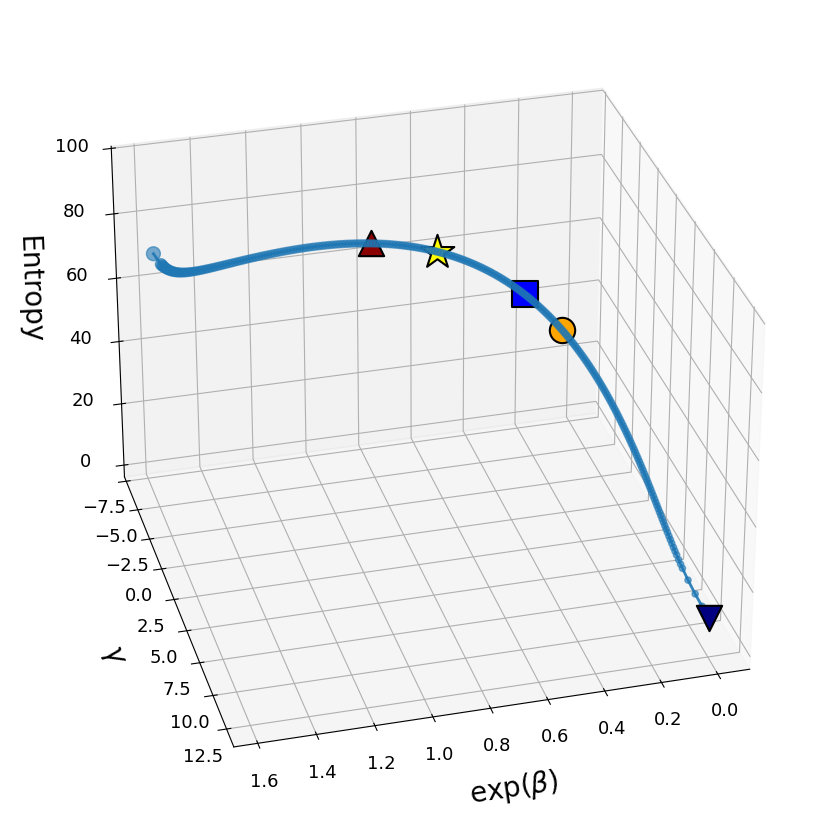

In [10]:
plot_curve_3d(
    curve,
    z_column="entropy",
    z_label="Entropy",
    highlight_points=highlights,
)

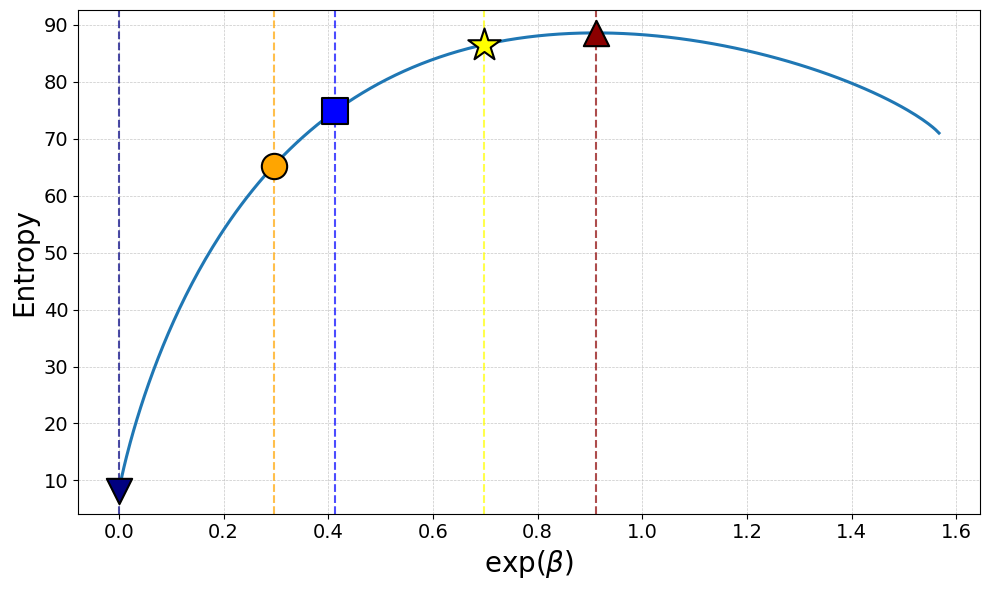

In [11]:
plot_curve_2d(
    curve,
    x_column="g",
    y_column="entropy",
    x_label=r"exp($\beta$)",
    y_label="Entropy",
    highlight_points=highlights,
)

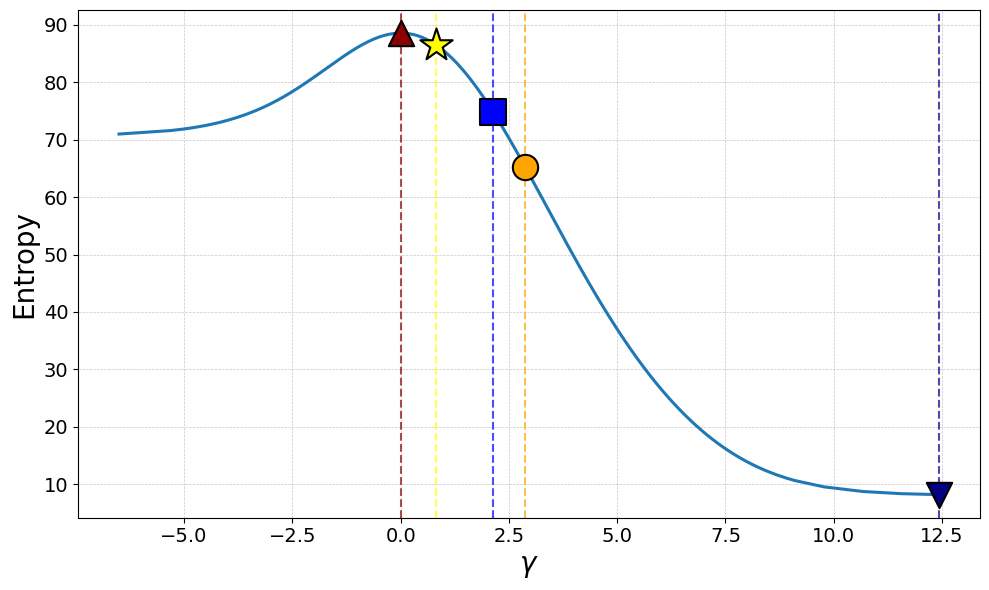

In [12]:
plot_curve_2d(
    curve,
    x_column="gamma",
    y_column="entropy",
    x_label=r"$\gamma$",
    y_label="Entropy",
    sort_within="gamma",
    highlight_points=highlights,
)

The same curve can be plotted on the log-likelihood scale, as in the paper's
log-likelihood figures.

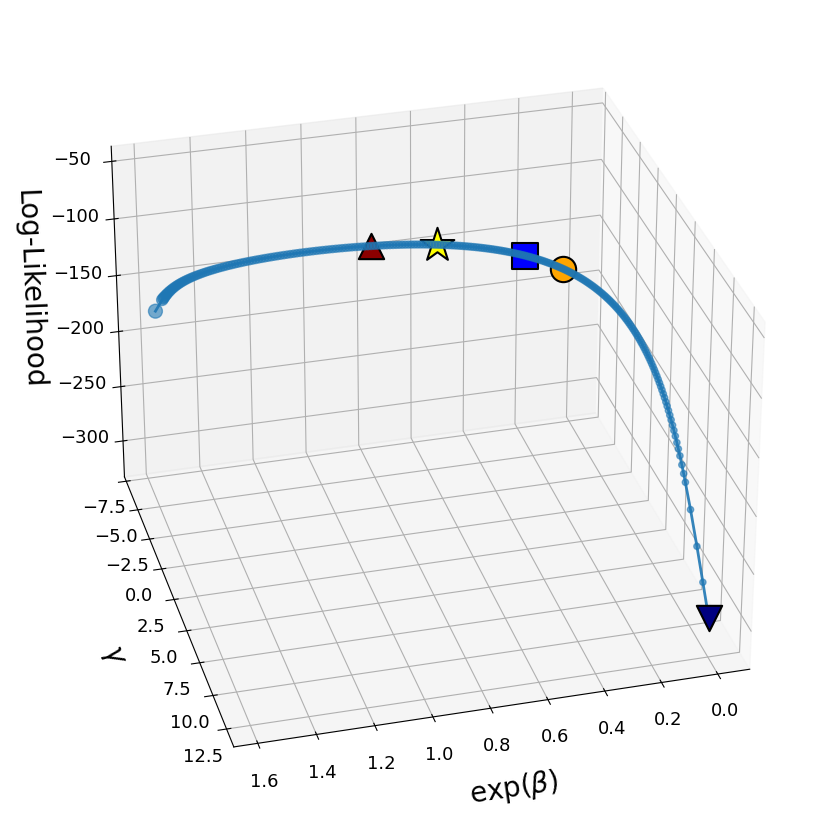

In [13]:
plot_curve_3d(
    curve,
    z_column="loglik",
    z_label="Log-Likelihood",
    highlight_points=highlights,
)

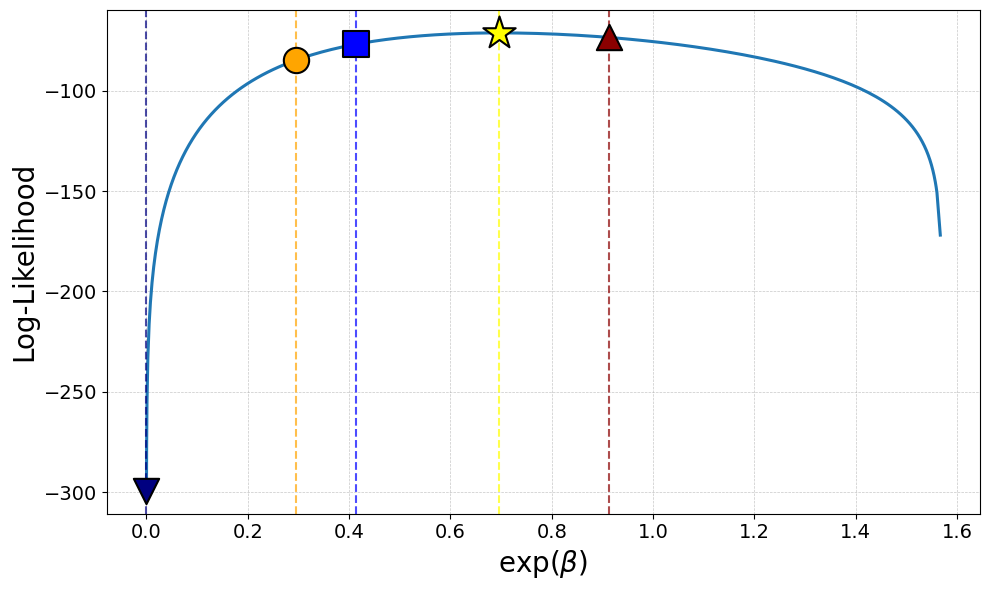

In [14]:
plot_curve_2d(
    curve,
    x_column="g",
    y_column="loglik",
    x_label=r"exp($\beta$)",
    y_label="Log-Likelihood",
    highlight_points=highlights,
)

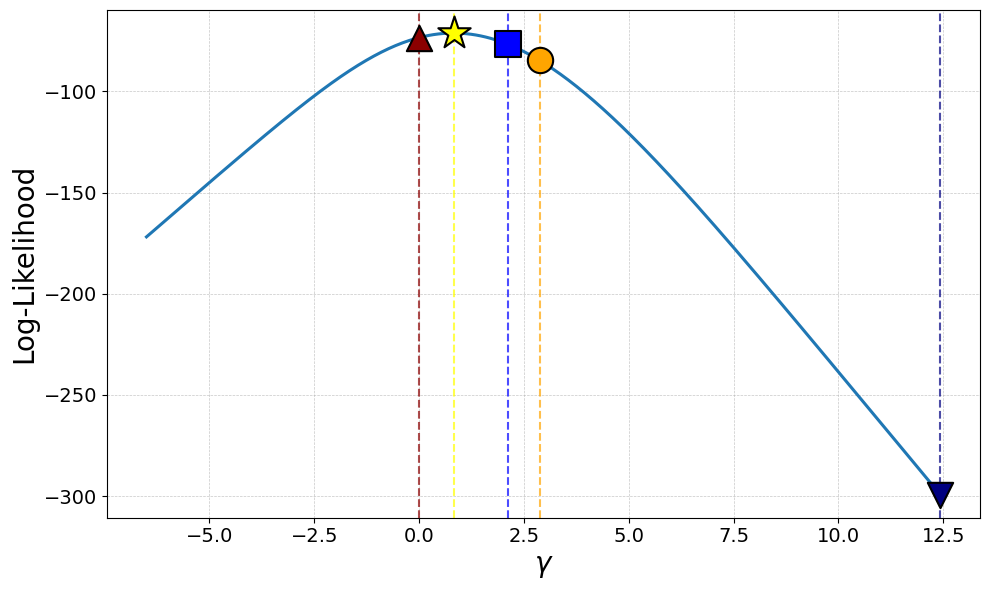

In [15]:
plot_curve_2d(
    curve,
    x_column="gamma",
    y_column="loglik",
    x_label=r"$\gamma$",
    y_label="Log-Likelihood",
    sort_within="gamma",
    highlight_points=highlights,
)

## 9. Export tables if needed

Uncomment the following lines to save the generated synthetic inputs and curve
outputs.

In [16]:
# country_df.to_csv("synthetic_country_df.csv", index=False)
# adj_matrix.to_csv("synthetic_adjacency.csv")
# curve.to_csv("synthetic_jeffreys_curve.csv", index=False)
# highlight_table.to_csv("synthetic_highlight_points.csv", index=False)
# metrics_table.to_csv("synthetic_metrics.csv")